In [1]:
import pandas as pd 

# Distribution pour la Hongrie 

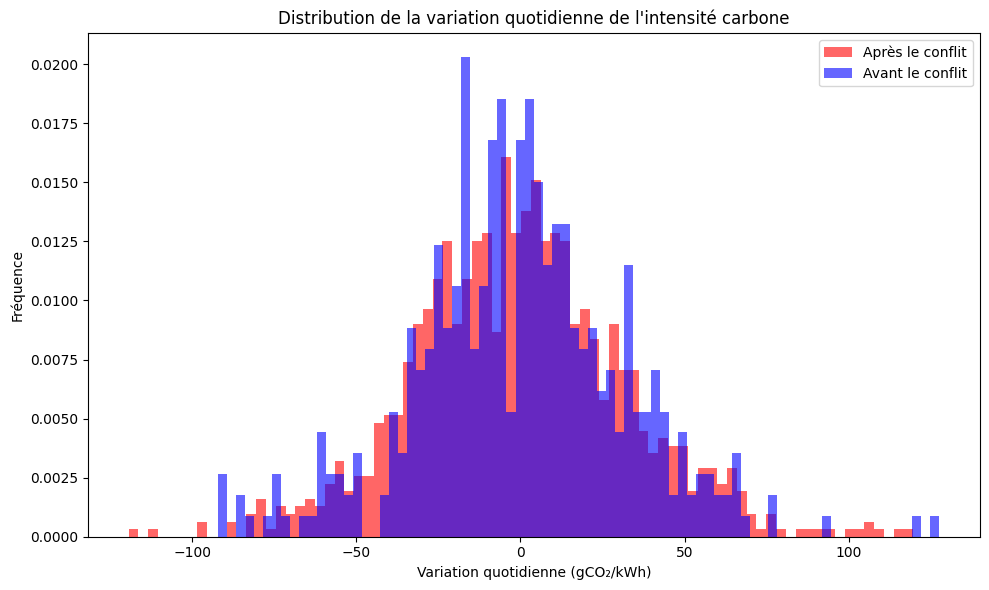

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Lire le dataset
df = pd.read_csv('hongrie_concatene.csv')

# Convertir la colonne 'Datetime (UTC)' en datetime
df['Datetime (UTC)'] = pd.to_datetime(df['Datetime (UTC)'])

# Trier les données par date
df = df.sort_values(by='Datetime (UTC)')

# Calculer la variation quotidienne de la colonne 'Carbon Intensity gCO₂eq/kWh (LCA)'
df['Variation'] = df['Carbon Intensity gCO₂eq/kWh (LCA)'].diff(7)



# Définir la date du conflit en Ukraine
date_conflit = pd.to_datetime('2022-02-24')

# Séparer les données avant et après le conflit
df_avant_conflit = df[df['Datetime (UTC)'] < date_conflit]
df_apres_conflit = df[df['Datetime (UTC)'] >= date_conflit]

# Tracer les distributions de la variation quotidienne avant et après le conflit avec transparence
plt.figure(figsize=(10, 6))

# Tracer l'histogramme de la variation quotidienne après le conflit avec transparence
plt.hist(df_apres_conflit['Variation'].dropna(), bins=80, color='red', alpha=0.6, label='Après le conflit', density=True)
# Tracer l'histogramme de la variation quotidienne avant le conflit avec transparence
plt.hist(df_avant_conflit['Variation'].dropna(), bins=80, color='blue', alpha=0.6, label='Avant le conflit', density=True)


# Ajouter les labels et la légende
plt.title('Distribution de la variation quotidienne de l\'intensité carbone')
plt.xlabel('Variation quotidienne (gCO₂/kWh)')
plt.ylabel('Fréquence')
plt.legend(loc='upper right')

# Afficher le graphique
plt.tight_layout()
plt.show()



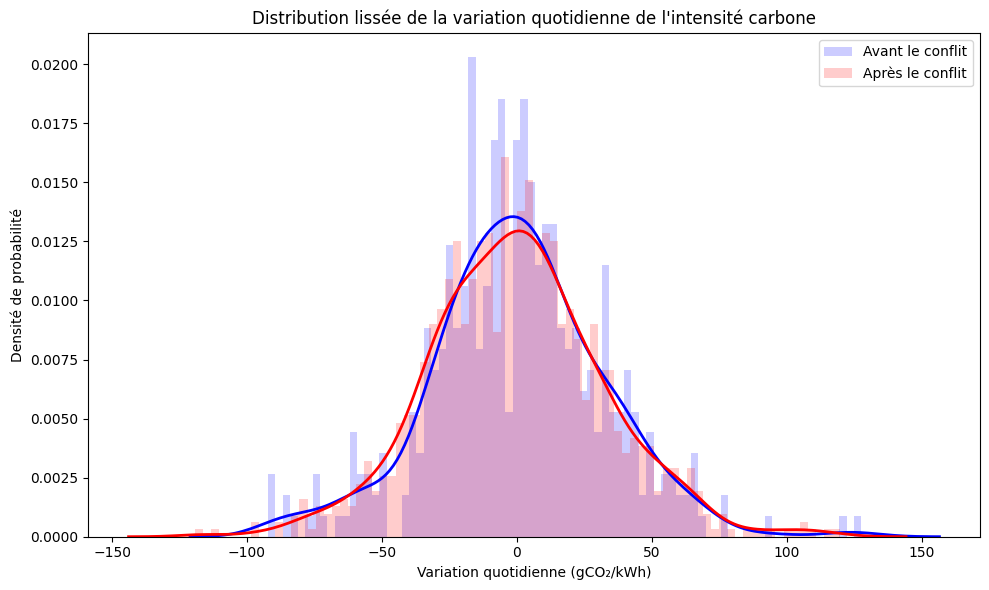

Statistique KS : 0.0414, p-value : 0.6741, différence entre courbes statistiquement significative si p<0,05
Avant conflit : écart-type = 32.12188168127344
Après conflit : écart-type = 32.740259283725884


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Préparer les données
df_avant = df[df['Datetime (UTC)'] < pd.to_datetime('2022-02-24')]['Variation'].dropna()
df_apres = df[df['Datetime (UTC)'] >= pd.to_datetime('2022-02-24')]['Variation'].dropna()

plt.figure(figsize=(10, 6))

# Histogrammes légers (alpha faible)
sns.histplot(df_avant, bins=80, color='blue', label='Avant le conflit',
             kde=False, stat='density', alpha=0.2, edgecolor=None)
sns.histplot(df_apres, bins=80, color='red', label='Après le conflit',
             kde=False, stat='density', alpha=0.2, edgecolor=None)

# Courbes KDE pour lisser
sns.kdeplot(df_avant, color='blue', linewidth=2)
sns.kdeplot(df_apres, color='red', linewidth=2)

# Légendes et titres
plt.title("Distribution lissée de la variation quotidienne de l'intensité carbone")
plt.xlabel("Variation quotidienne (gCO₂/kWh)")
plt.ylabel("Densité de probabilité")
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


statistic, p_value = ks_2samp(df_avant, df_apres)
print(f"Statistique KS : {statistic:.4f}, p-value : {p_value:.4f}, différence entre courbes statistiquement significative si p<0,05")

print("Avant conflit : écart-type =", df_avant.std())
print("Après conflit : écart-type =", df_apres.std())


In [16]:
df_avant_conflit[df_avant_conflit['Variation'] > 0].sum()['Variation'], df_avant_conflit[df_avant_conflit['Variation'] < 0].sum()['Variation']

C:\Users\flobm\AppData\Local\Temp\ipykernel_33432\3823117669.py:1: FutureWarning: The default value of numeric_only in DataFrame.sum is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_avant_conflit[df_avant_conflit['Variation'] > 0].sum()['Variation'], df_avant_conflit[df_avant_conflit['Variation'] < 0].sum()['Variation']
C:\Users\flobm\AppData\Local\Temp\ipykernel_33432\3823117669.py:1: FutureWarning: The default value of numeric_only in DataFrame.sum is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_avant_conflit[df_avant_conflit['Variation'] > 0].sum()['Variation'], df_avant_conflit[df_avant_conflit['Variation'] < 0].sum()['Variation']


(3544.5999999999995, -3475.7)

In [17]:
df_apres_conflit[df_apres_conflit['Variation'] > 0].sum()['Variation'], df_apres_conflit[df_apres_conflit['Variation'] < 0].sum()['Variation']

C:\Users\flobm\AppData\Local\Temp\ipykernel_33432\2782111414.py:1: FutureWarning: The default value of numeric_only in DataFrame.sum is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_apres_conflit[df_apres_conflit['Variation'] > 0].sum()['Variation'], df_apres_conflit[df_apres_conflit['Variation'] < 0].sum()['Variation']
C:\Users\flobm\AppData\Local\Temp\ipykernel_33432\2782111414.py:1: FutureWarning: The default value of numeric_only in DataFrame.sum is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_apres_conflit[df_apres_conflit['Variation'] > 0].sum()['Variation'], df_apres_conflit[df_apres_conflit['Variation'] < 0].sum()['Variation']


(9435.49, -9454.93)

In [4]:
import pandas as pd

# Lire le dataset
df = pd.read_csv('hongrie_concatene.csv')

# Convertir la colonne 'Datetime (UTC)' en datetime
df['Datetime (UTC)'] = pd.to_datetime(df['Datetime (UTC)'])

# Trier les données par date
df = df.sort_values(by='Datetime (UTC)')

# Définir la date du conflit en Ukraine
date_conflit = pd.to_datetime('2022-02-24')

# Séparer les données avant et après le conflit
df_avant_conflit = df[df['Datetime (UTC)'] < date_conflit]
df_apres_conflit = df[df['Datetime (UTC)'] >= date_conflit]

# Calculer la moyenne pour chaque période
moyenne_avant_conflit = df_avant_conflit['Carbon Intensity gCO₂eq/kWh (LCA)'].mean()
moyenne_apres_conflit = df_apres_conflit['Carbon Intensity gCO₂eq/kWh (LCA)'].mean()

# Afficher les résultats
print(f"Moyenne avant le conflit (2022-02-24) : {moyenne_avant_conflit}")
print(f"Moyenne après le conflit (2022-02-24) : {moyenne_apres_conflit}")


Moyenne avant le conflit (2022-02-24) : 304.0844630071599
Moyenne après le conflit (2022-02-24) : 262.735508637236


# Distribution pour la France

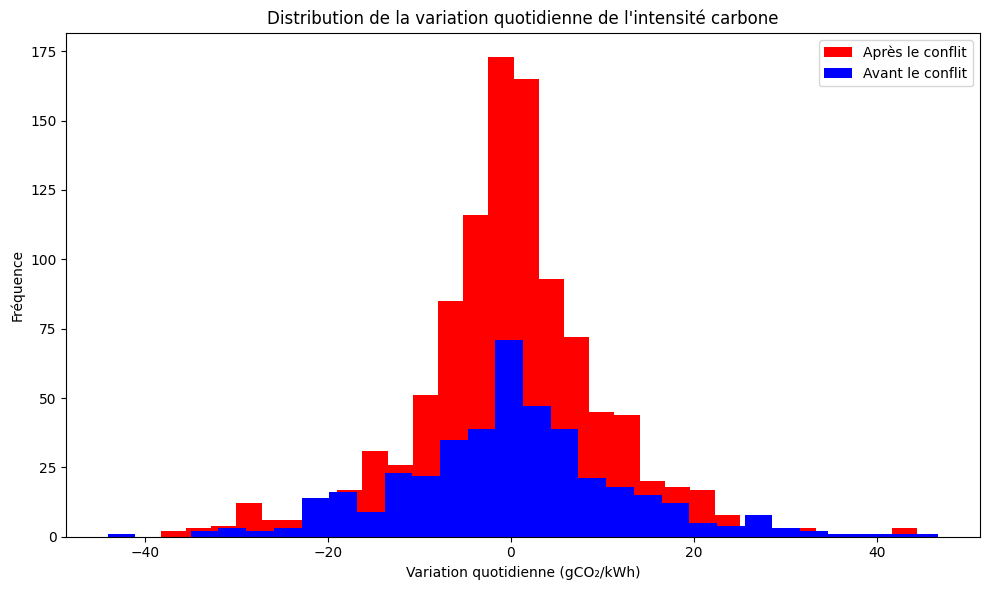

In [6]:
# Lire le dataset
dff = pd.read_csv('france_concatene.csv')

# Convertir la colonne 'Datetime (UTC)' en datetime
dff['Datetime (UTC)'] = pd.to_datetime(df['Datetime (UTC)'])

# Trier les données par date
dff = dff.sort_values(by='Datetime (UTC)')

# Calculer la variation quotidienne de la colonne 'Carbon Intensity gCO₂eq/kWh (LCA)'
dff['Variation'] = dff['Carbon Intensity gCO₂eq/kWh (LCA)'].diff()

# Définir la date du conflit en Ukraine
date_conflit = pd.to_datetime('2022-02-24')

# Séparer les données avant et après le conflit
dff_avant_conflit = dff[dff['Datetime (UTC)'] < date_conflit]
dff_apres_conflit = dff[dff['Datetime (UTC)'] >= date_conflit]

# Tracer les distributions de la variation quotidienne avant et après le conflit avec transparence
plt.figure(figsize=(10, 6))

# Tracer l'histogramme de la variation quotidienne après le conflit avec transparence
plt.hist(dff_apres_conflit['Variation'].dropna(), bins=30, color='red', alpha=1., label='Après le conflit')

# Tracer l'histogramme de la variation quotidienne avant le conflit avec transparence
plt.hist(dff_avant_conflit['Variation'].dropna(), bins=30, color='blue', alpha=1., label='Avant le conflit')



# Ajouter les labels et la légende
plt.title('Distribution de la variation quotidienne de l\'intensité carbone')
plt.xlabel('Variation quotidienne (gCO₂/kWh)')
plt.ylabel('Fréquence')
plt.legend(loc='upper right')

# Afficher le graphique
plt.tight_layout()
plt.show()

### Idées de régression sur séries temporelles

- arima, sarima, arimax pour comparer prédictions 
- 